## Prerequisites:

1. `lalsuite`'s ESIGMA branch should be installed (and sourced!) $\rightarrow$ required for the inspiral piece.
2. `NRSur7dq4`'s [data file](https://git.ligo.org/lscsoft/lalsuite-extra/-/blob/master/data/lalsimulation/NRSur7dq4.h5) should be downloaded (for LALSuite versions >= 7.25, download [this data file](https://git.ligo.org/waveforms/software/lalsuite-waveform-data/-/blob/main/waveform_data/NRSur7dq4_v1.0.h5?ref_type=heads) instead), with the path to the directory containing it been set to the bash environment variable `LAL_DATA_PATH` $\rightarrow$ required for the merger-ringdown piece.

The detailed instructions to set these up are present on the [git repository](https://github.com/gwnrtools/esigmapy).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import esigmapy

# Configuring some plot settings
plt.rcParams.update(
    {
        "text.usetex": False,
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "font.size": 12,
    }
)

No version information file '.version' found


## IMRESIGMA

### Waveform polarizations
The polarizations $h_+$ and $h_\times$ can be generated via the `get_imr_esigma_waveform` function. They are returned as `PyCBC` `TimeSeries` objects.

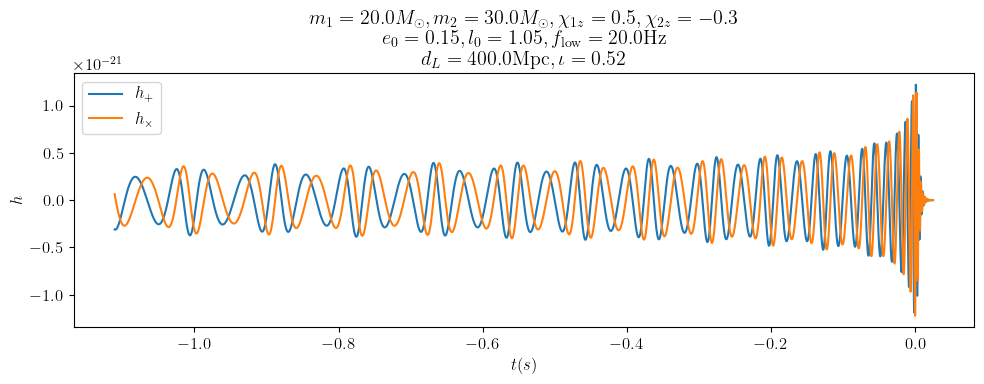

In [2]:
m1 = 20.0  # masses (in solar masses)
m2 = 30.0
spin1z = 0.5  # dimensionless spins
spin2z = -0.3
eccentricity = 0.15  # starting eccentricity
mean_anomaly = 60 * np.pi / 180.0  # starting mean anomaly
modes_to_use = [(2, 2), (2, -2)]  # Only using the (2,2) mode

distance = 400.0  # source luminosity distance (in Mpc)
inclination = 30 * np.pi / 180.0  # orbital inclination with line-of-sight

f_low = 20.0  # starting frequency (in Hz)
delta_t = 1 / 2**12  # time grid-spacing (in s)

hp, hc = esigmapy.get_imr_esigma_waveform(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
)

plt.figure(figsize=(10, 4))
plt.title(
    rf"""$m_1={m1} M_\odot, m_2={m2} M_\odot, \chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$ 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)
hp.plot(label=r"$h_+$")
hc.plot(label=r"$h_\times$")
plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.legend()
plt.tight_layout()

One can also specify the eccentricity and mean anomaly at some reference frequency $f_{\rm{ref}}$ different from the starting frequency $f_{\rm{low}}$ of the waveform.

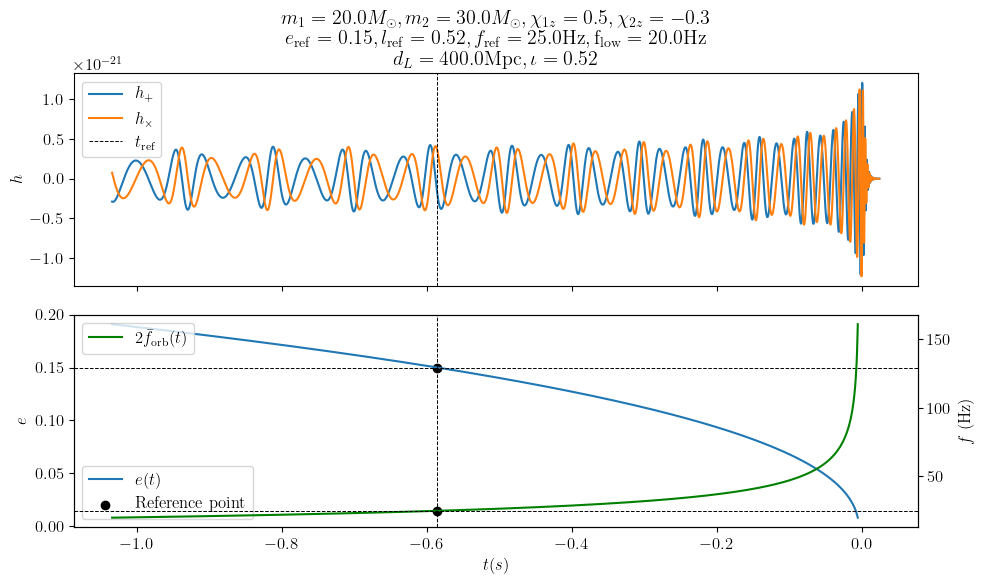

In [3]:
f_ref = 25.0
f_low = 20.0

# This time, the following eccentricity and mean anomaly values are
# defined at f_ref, and not at f_low
eccentricity = 0.15
mean_anomaly = 30.0 * np.pi / 180.0

hp, hc, orb_vars = esigmapy.get_imr_esigma_waveform(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    inclination=inclination,
    f_ref=f_ref,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    # Returns orbital variables' evolution; explained below
    return_orbital_params=["x", "e"],
)

######### Plotting #################
from esigmapy.utils import f22_from_x

t_imr = hp.sample_times.data
t = orb_vars["e"].sample_times.data
# Orbital variables are only available for
# inspiral potion, so the IMR waveform's time grid
# is longer and shifted as compared to inspiral's
t_shift = t[0] - t_imr[0]
# Making the inspiral time grid start
# at the same time as the IMR grid
t -= t_shift
e = orb_vars["e"].data

# Getting the orbit-averaged GW frequency from
# ESIGMA's PN parameter x. This is the frequency
# that is set when supplying f_lower/f_ref to ESIGMA.
f_22 = f22_from_x(orb_vars["x"].data, M=m1 + m2)
if f_ref is None or f_ref <= f_low:
    ref_idx = 0
else:
    ref_idx = np.argmax(f_22 >= f_ref)
t_ref = t[ref_idx]
e_ref = e[ref_idx]
f_22_ref = f_22[ref_idx]

fig, axs = plt.subplots(2, sharex=True, figsize=(10, 6))
axs[0].set_title(
    rf"""$m_1={m1} M_\odot, m_2={m2} M_\odot, \chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$ 
          $e_{{\rm{{ref}}}}={eccentricity}, l_{{\rm{{ref}}}}={mean_anomaly:.2f}, f_{{\rm{{ref}}}}={f_ref}\rm{{Hz}}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)
axs[0].plot(t_imr, hp.data, label=r"$h_+$")
axs[0].plot(t_imr, hc.data, label=r"$h_\times$")
if f_ref >= f_low:
    axs[0].axvline(t_ref, color="k", ls="--", lw=0.7, label=r"$t_{\rm{ref}}$")
    axs[0].set_ylabel(r"$h$")
axs[0].legend()

# Plotting the reference point at which eccentricity was defined
# in the eccentricity evolution plot
axsL = axs[1]
axsR = axsL.twinx()
axsL.plot(t, e, label=r"$e(t)$")
axsR.plot(t, f_22, label=r"$2 \bar{f}_{\rm{orb}}(t)$", color="green")
if f_ref >= f_low:
    axsL.scatter(t_ref, e_ref, color="k", label=r"Reference point")
    axsL.axvline(t_ref, color="k", ls="--", lw=0.7)
    axsL.axhline(e_ref, color="k", ls="--", lw=0.7)

    axsR.scatter(t_ref, f_22_ref, color="k")
    axsR.axhline(f_22_ref, color="k", ls="--", lw=0.7)

axsL.set_ylabel(r"$e$")
axsR.set_ylabel(r"$f$ (Hz)")
axs[1].legend()

axs[1].set_xlabel(r"$t (s)$")
plt.legend()
plt.tight_layout()

### Waveform modes
One can also generate the spin-weighted spherical harmonic modes via the `get_imr_esigma_modes` function.

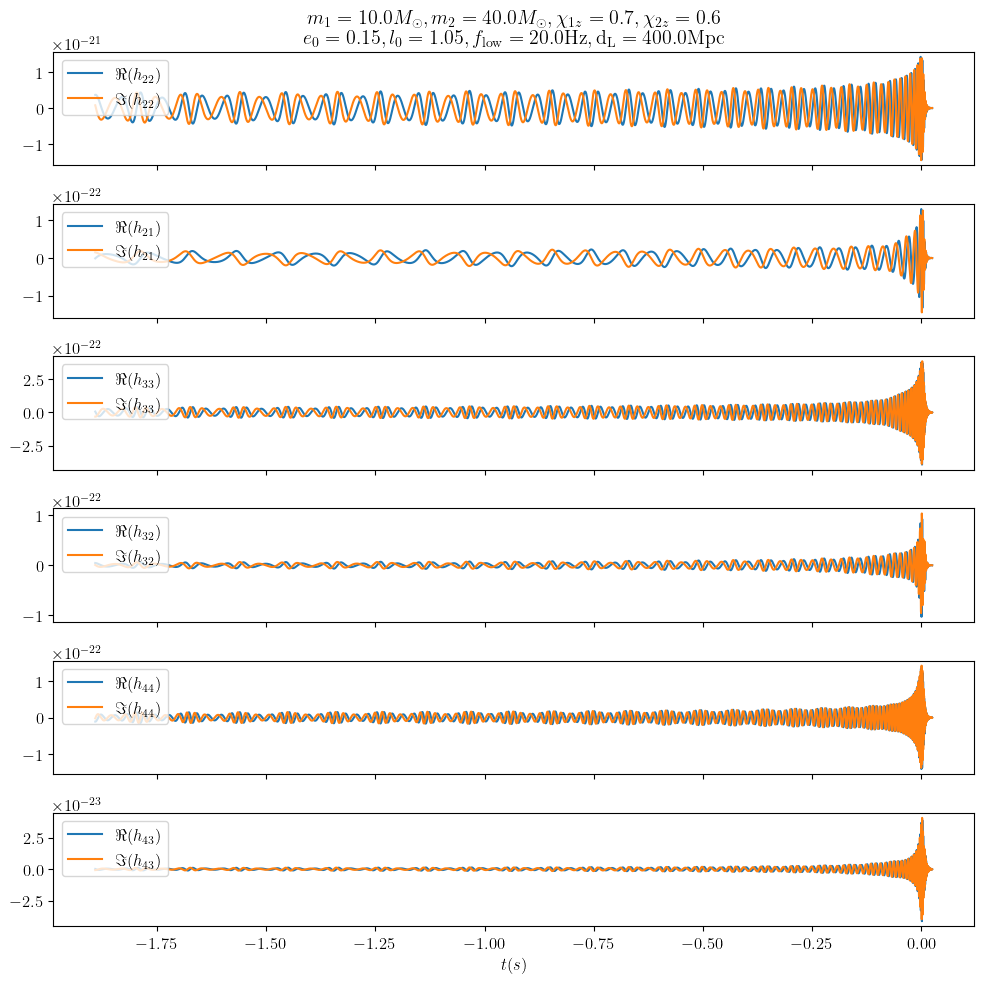

In [4]:
m1 = 10.0  # masses (in solar masses)
m2 = 40.0
spin1z = 0.7  # dimensionless spins
spin2z = 0.6
eccentricity = 0.15  # starting eccentricity
mean_anomaly = 60 * np.pi / 180.0  # starting mean anomaly

distance = 400.0  # source luminosity distance (in Mpc)
inclination = 30 * np.pi / 180.0  # orbital inclination with line-of-sight

f_low = 20.0  # starting frequency (in Hz)
delta_t = 1 / 2**12  # time grid-spacing (in s)

modes_to_use = [(2, 2), (2, 1), (3, 3), (3, 2), (4, 4), (4, 3)]

modes = esigmapy.get_imr_esigma_modes(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    include_conjugate_modes=False,
)

fig, axs = plt.subplots(len(modes_to_use), sharex=True, figsize=(10, 10))
axs[0].set_title(
    rf"""$m_1={m1} M_\odot, m_2={m2} M_\odot, \chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$ 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}, d_L={distance}\rm{{Mpc}}$"""
)
for i, mode_name in enumerate(modes_to_use):
    ell, m = mode_name
    axs[i].plot(
        modes[mode_name].sample_times.data,
        modes[mode_name].real().data,
        label=rf"$\Re(h_{{{ell} {m}}})$",
    )
    axs[i].plot(
        modes[mode_name].sample_times.data,
        modes[mode_name].imag().data,
        label=rf"$\Im(h_{{{ell} {m}}})$",
    )
    axs[i].legend(loc=2)
plt.xlabel(r"$t (s)$")
plt.tight_layout()

Other options related to hybridization settings, merger-ringdown model choice, etc. are available as well. One can check them in the respective docstrings of the functions like so:

In [5]:
help(esigmapy.get_imr_esigma_waveform)

Help on function get_imr_esigma_waveform in module esigmapy.generator:

get_imr_esigma_waveform(mass1, mass2, f_lower, delta_t, f_ref=None, spin1z=0.0, spin2z=0.0, eccentricity=0.0, mean_anomaly=0.0, coa_phase=0.0, inclination=0.0, distance=1.0, modes_to_use=[(2, 2), (3, 3), (4, 4)], mode_to_align_by=(2, 2), f_mr_transition=None, f_window_mr_transition=None, num_hyb_orbits=0.25, blend_using_avg_orbital_frequency=True, blend_aligning_merger_to_inspiral=True, keep_f_mr_transition_at_center=False, merger_ringdown_approximant='NRSur7dq4', return_hybridization_info=False, return_orbital_params=False, failsafe=True, verbose=False, **kwargs)
    Returns IMR GW polarizations constructed using IMR ESIGMA modes
    
    Parameters:
    -----------
        mass1, mass2              -- Binary's component masses (in solar masses)
        f_lower                   -- Starting frequency of the waveform (in Hz)
        f_ref                     -- Reference frequency at which to define the
           

## InspiralESIGMA

One can also generate the inspiral-only wavefroms and modes via the `get_inspiral_esigma_waveform` and `get_inspiral_esigma_modes` functions respectively. Unlike the full IMR waveform which uses a quasi-circular merger-ringdown model and thus forbids using large starting eccentricities, the inspiral waveforms can be generated for arbitrarily eccentric (bounded) orbits (i.e. with $0 \leq e < 1$).

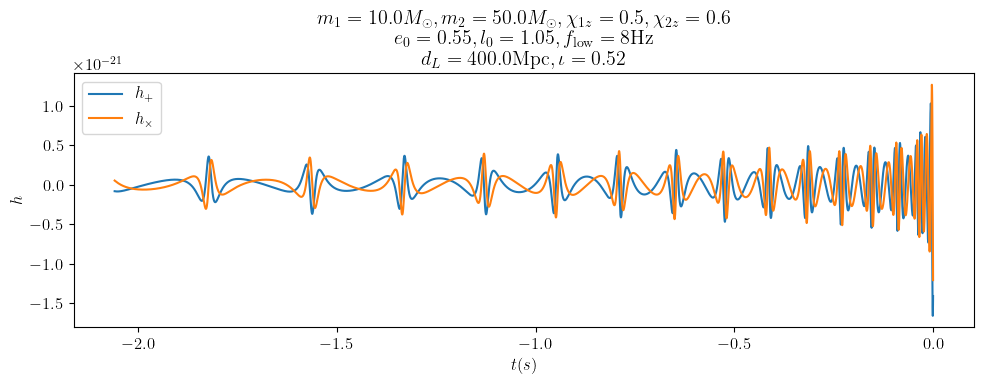

In [6]:
m1 = 10.0  # masses (in solar masses)
m2 = 50.0
spin1z = 0.5  # dimensionless spins
spin2z = 0.6
eccentricity = 0.55  # starting eccentricity
mean_anomaly = 60 * np.pi / 180.0  # starting mean anomaly
modes_to_use = [(2, 2), (2, -2)]  # Only using the (2,2) mode

distance = 400.0  # source luminosity distance (in Mpc)
inclination = 30 * np.pi / 180.0  # orbital inclination with line-of-sight

f_low = 8  # starting frequency (in Hz)
delta_t = 1 / 2**12  # time grid-spacing (in s)

hp, hc = esigmapy.get_inspiral_esigma_waveform(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
)
plt.figure(figsize=(10, 4))
plt.title(
    rf"""$m_1={m1} M_\odot, m_2={m2} M_\odot, \chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$ 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)
hp.plot(label=r"$h_+$")
hc.plot(label=r"$h_\times$")
plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.legend()
plt.tight_layout()

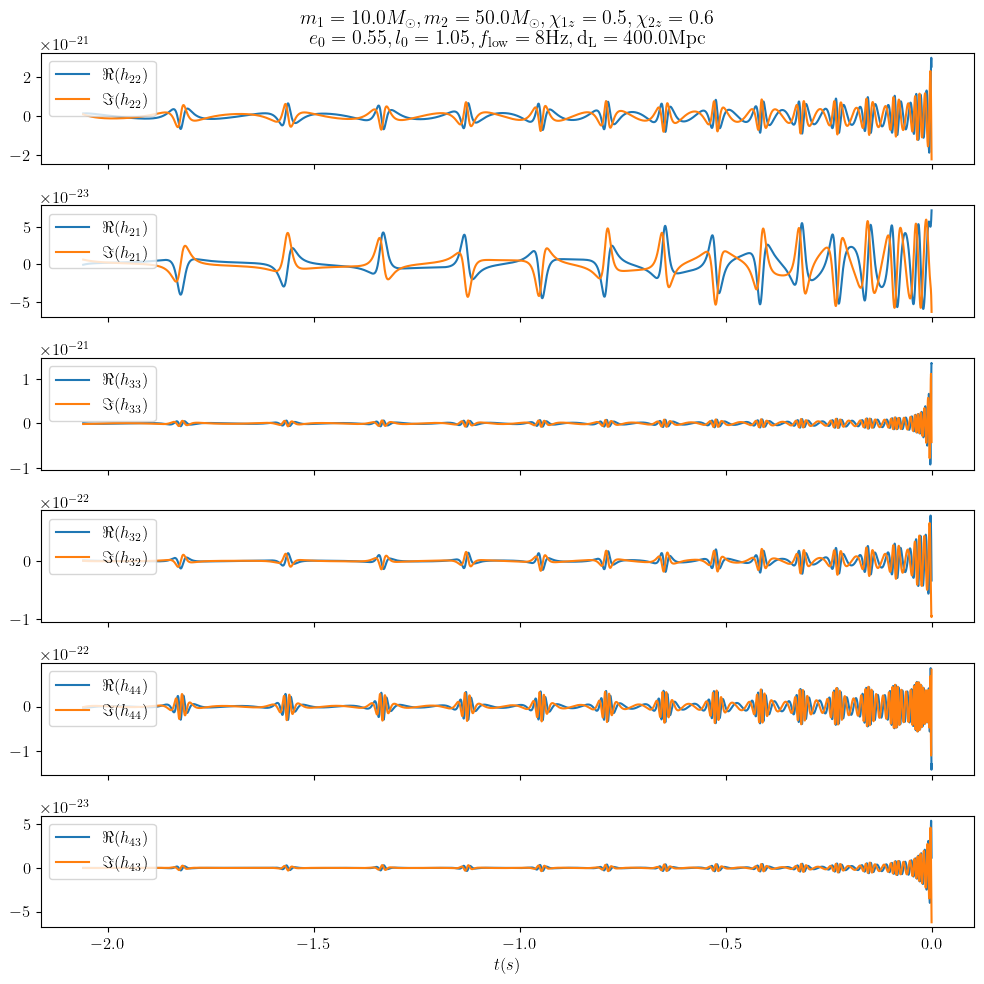

In [7]:
modes_to_use = [(2, 2), (2, 1), (3, 3), (3, 2), (4, 4), (4, 3)]

modes = esigmapy.get_inspiral_esigma_modes(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    include_conjugate_modes=False,
)

fig, axs = plt.subplots(len(modes_to_use), sharex=True, figsize=(10, 10))
axs[0].set_title(
    rf"""$m_1={m1} M_\odot, m_2={m2} M_\odot, \chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$ 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}, d_L={distance}\rm{{Mpc}}$"""
)
for i, mode_name in enumerate(modes_to_use):
    ell, m = mode_name
    axs[i].plot(
        modes[mode_name].sample_times.data,
        modes[mode_name].real().data,
        label=rf"$\Re(h_{{{ell} {m}}})$",
    )
    axs[i].plot(
        modes[mode_name].sample_times.data,
        modes[mode_name].imag().data,
        label=rf"$\Im(h_{{{ell} {m}}})$",
    )
    axs[i].legend(loc=2)
plt.xlabel(r"$t (s)$")
plt.tight_layout()

## Evolution of orbital elements
The evolution of binary's orbital elements can also be accessed, but only for the *inspiral part of the dynamics*. These can be accessed via the argument `return_orbital_params` in all of the above discussed waveform/mode functions. The available orbital elements are

- $x$: The post-Newtonian (PN) parameter. It's related to the orbit-averaged (azimuthal) orbital frequency
- $e$: Orbital eccentricity
- $l$: Mean anomaly
- $r$: Relative separation
- $\dot{r}$: Radial velocity
- $\phi$: Orbital phase
- $\dot{\phi}$: Angular velocity

All of these are returned in geometric units ($G=c=1$).

Text(0.5, 0, '$t (s)$')

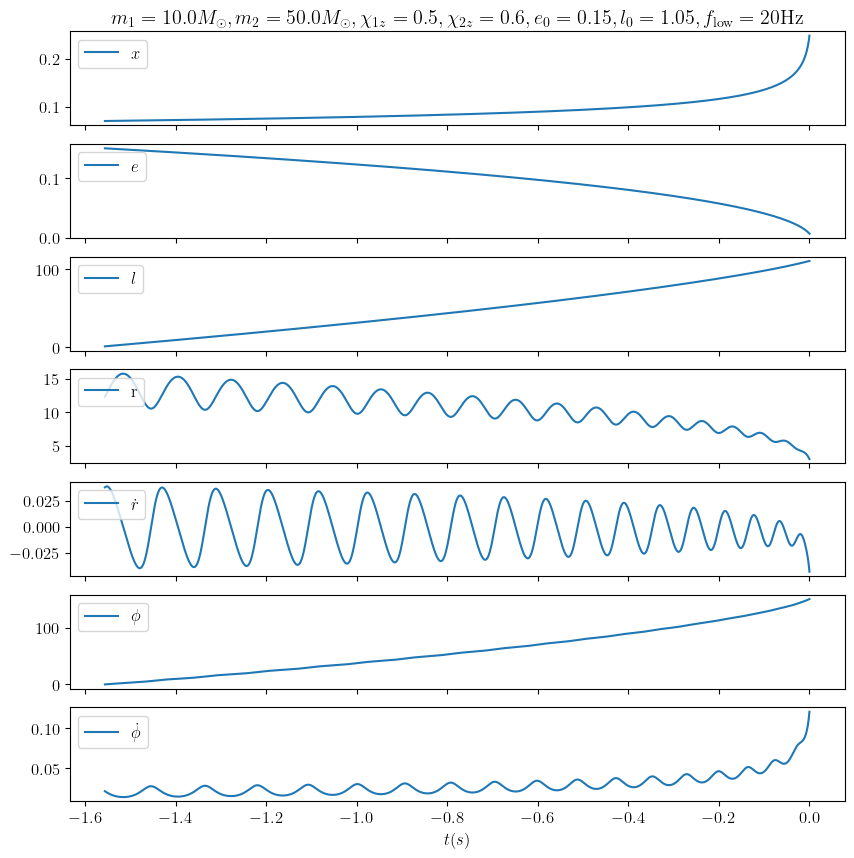

In [8]:
m1 = 10.0  # masses (in solar masses)
m2 = 50.0
spin1z = 0.5  # dimensionless spins
spin2z = 0.6
eccentricity = 0.15  # starting eccentricity
mean_anomaly = 60 * np.pi / 180.0  # starting mean anomaly
modes_to_use = [(2, 2), (2, -2)]  # Only using the (2,2) mode
orb_params_list = ["x", "e", "l", "r", "rdot", "phi", "phidot"]

distance = 400.0  # source luminosity distance (in Mpc)
inclination = 30 * np.pi / 180.0  # orbital inclination with line-of-sight

f_low = 20  # starting frequency (in Hz)
delta_t = 1 / 2**12  # time grid-spacing (in s)

orb_vars, hp, hc = esigmapy.get_inspiral_esigma_waveform(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    return_orbital_params=orb_params_list,
)

fig, axs = plt.subplots(len(orb_params_list), sharex=True, figsize=(10, 10))
axs[0].set_title(
    rf"$m_1={m1} M_\odot, m_2={m2} M_\odot, \chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}, e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$"
)

orb_var_latex_labels = {
    "x": r"$x$",
    "e": r"$e$",
    "l": r"$l$",
    "r": r"r",
    "rdot": r"$\dot{r}$",
    "phi": "$\phi$",
    "phidot": r"$\dot{\phi}$",
}

for i, orb_params_name in enumerate(orb_params_list):
    axs[i].plot(
        orb_vars[orb_params_name].sample_times.data,
        orb_vars[orb_params_name].data,
        label=rf"{orb_var_latex_labels[orb_params_name]}",
    )
    axs[i].legend(loc=2)
plt.xlabel(r"$t (s)$")